In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [4]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck'])

Age ko median se fill kiya kyunke ismein bohat kam outliers ka asar padta hai. Deck column ko hata diya kyunke 77% se zyada data missing tha.

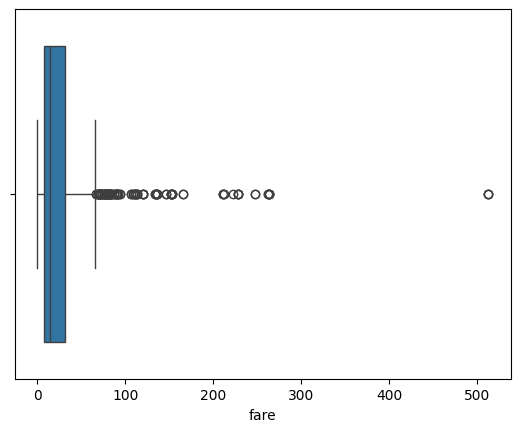

In [5]:
sns.boxplot(x=df['fare'])
plt.show()

Fare column mein kaafi outliers hain — kuch passengers ne bohat mehnge tickets liye the (first-class ke)

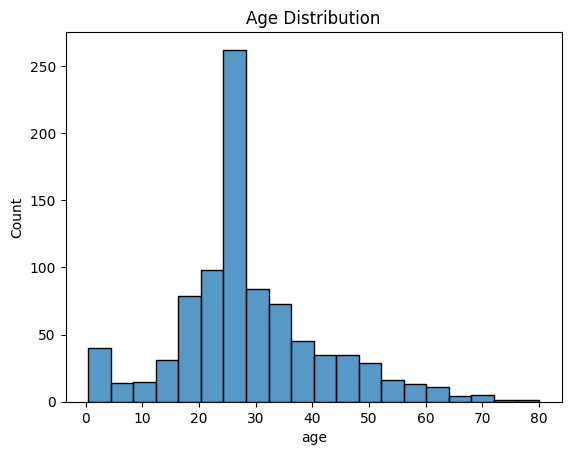

In [6]:
sns.histplot(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

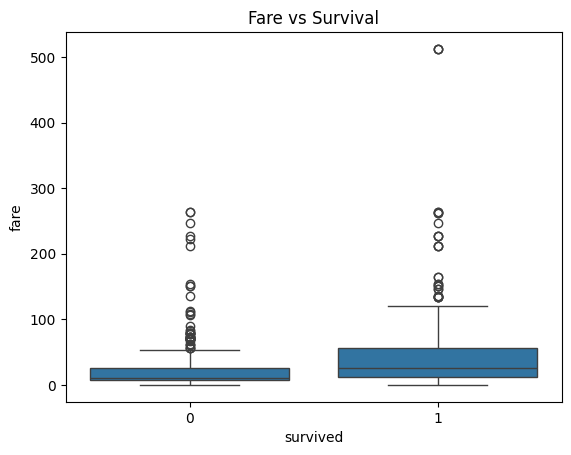

In [7]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare vs Survival')
plt.show()

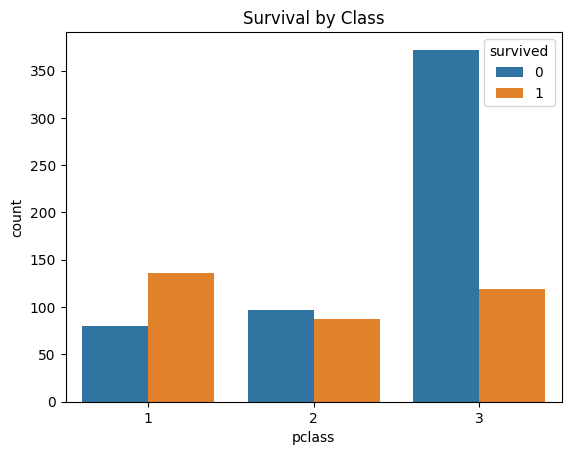

In [8]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Class')
plt.show()

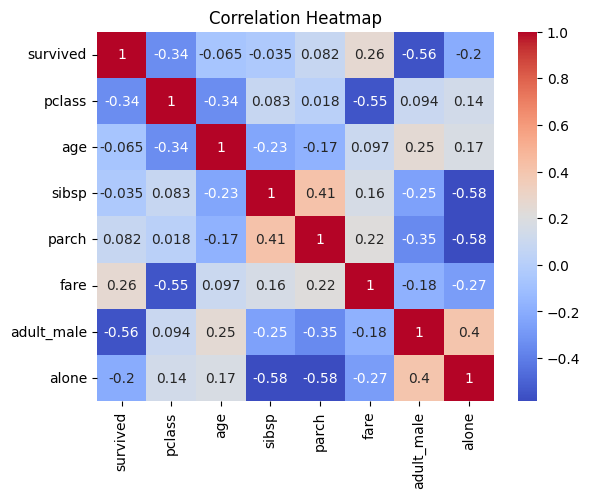

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Q: Which feature affects survival most?**
Heatmap aur bar chart dekh kar pata chalta hai ke sex aur pclass survival ko sabse zyada affect karte hain. Females ki survival rate males se kaafi zyada thi, aur first-class passengers third-class walon ke muqable mein zyada bache. Isse pata chalta hai ke us waqt "women and children first" wala rule follow hua tha, aur higher class walon ko lifeboats tak jaldi pohonch mili.